
# **Principal Component Analysis (PCA)**


Successfully loaded data from 'tmdb_movie_details.csv'.

Features have been standardized.

PCA applied, data transformed to 2 principal components.

--- Explained Variance Ratio ---
Explained variance ratio for each PCA component: [0.43778713 0.1885714 ]
Cumulative explained variance by 2 components: 0.63


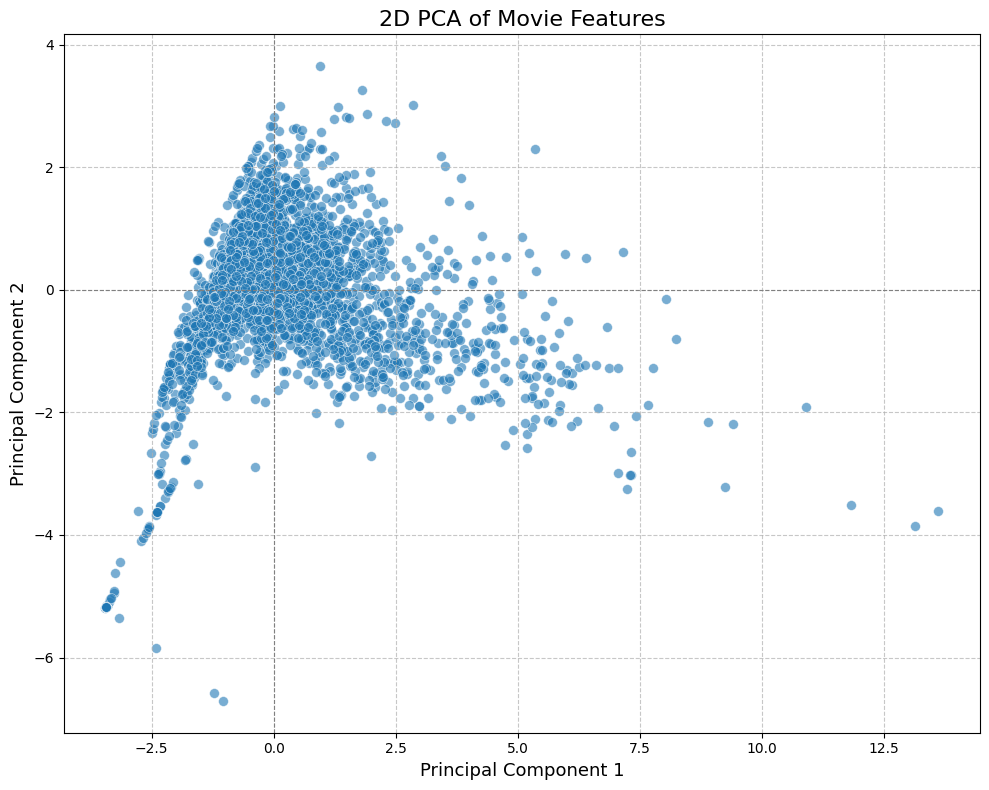


2D PCA visualization displayed.

--- Principal Component Analysis (PCA) Feature Importance (Loadings) ---

PCA Loadings (contribution of original features to each principal component):

                   PC1       PC2
vote_average  0.244395  0.738770
vote_count    0.521745 -0.096695
popularity    0.077055  0.065371
budget        0.501332 -0.319760
revenue_tmdb  0.540300 -0.279074
runtime       0.344758  0.510360


/tmp/ipython-input-3743346752.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pca_loadings.loc[top_features_pc1, 'PC1'], y=top_features_pc1, palette='viridis')
/tmp/ipython-input-3743346752.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pca_loadings.loc[top_features_pc2, 'PC2'], y=top_features_pc2, palette='viridis')


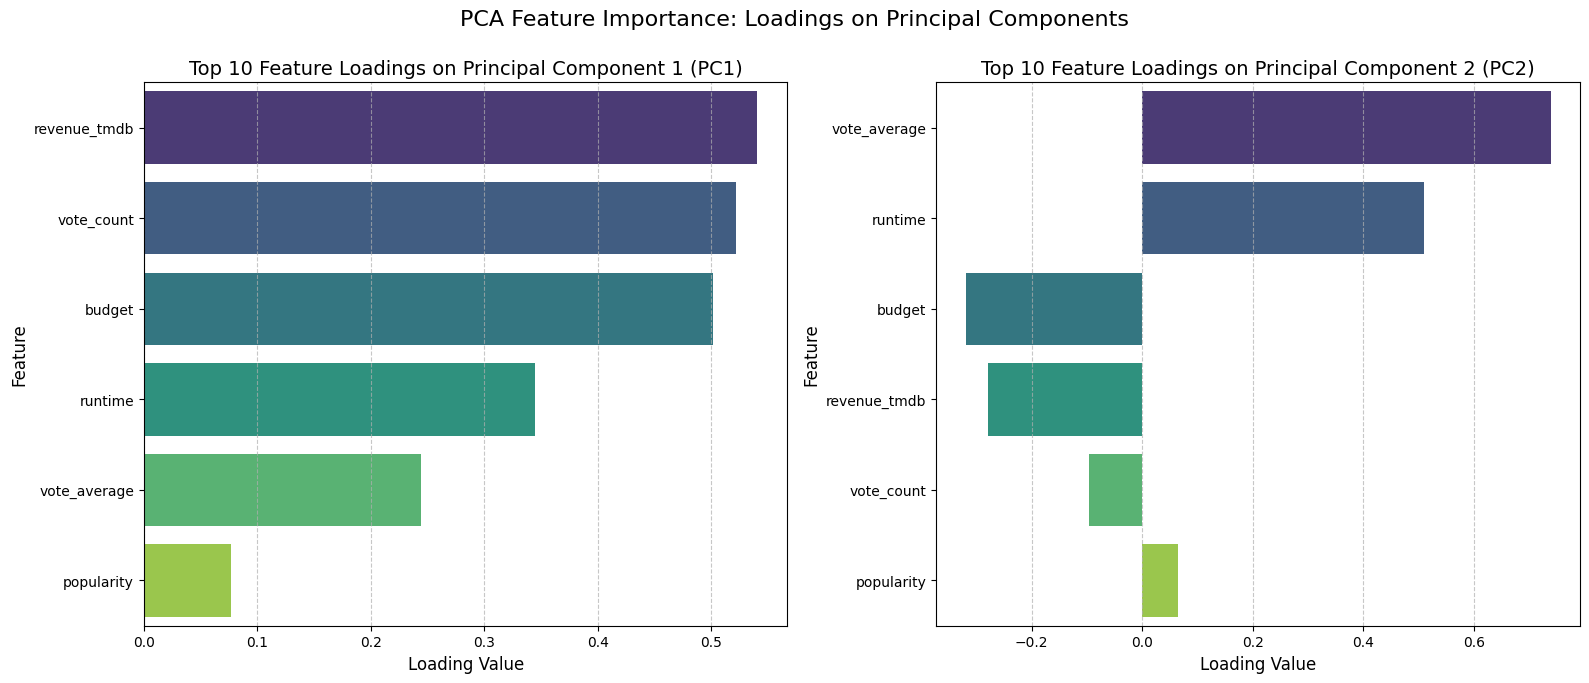

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for enhanced plotting capabilities

# --- 1. Data Loading ---
# Define the path to the CSV file
file_path = 'tmdb_movie_details.csv'

try:
    # Load the DataFrame from the specified CSV file
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from '{file_path}'.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the CSV file is in the correct directory.")
    exit() # Exit the script if the file is not found
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")
    exit() # Exit for other loading errors

# --- 2. Data Preparation ---
# Select only numerical columns from the DataFrame for PCA.
# PCA is a dimensionality reduction technique applied to numerical features.
numerical_cols = df.select_dtypes(include=['number']).columns

# Handle missing values in numerical columns by filling them with the mean of their respective columns.
# This is a common strategy to ensure PCA can run without issues caused by NaN values.
df_numerical = df[numerical_cols].fillna(df[numerical_cols].mean())

# Exclude identifier columns ('movie_id', 'imdb_id') from the features.
# These columns are unique identifiers and do not represent meaningful features for PCA.
features = df_numerical.drop(columns=['movie_id', 'imdb_id'], errors='ignore')

# Store the names of the features. This is crucial for interpreting PCA loadings later.
feature_names = features.columns

# --- 3. Feature Standardization ---
# Initialize the StandardScaler.
# Standardization (scaling features to have zero mean and unit variance) is a critical preprocessing step for PCA.
# This ensures that features with larger numerical ranges do not dominate the principal components.
scaler = StandardScaler()
# Fit the scaler to the features and then transform them.
scaled_features = scaler.fit_transform(features)
print("\nFeatures have been standardized.")

# --- 4. Principal Component Analysis (PCA) Application ---
# Initialize PCA, specifying n_components=2 to reduce the dimensionality to 2 principal components.
# These 2 components are chosen for easy visualization in a 2D scatter plot.
pca = PCA(n_components=2)
# Fit PCA to the scaled features and transform them into the new 2-dimensional space.
principal_components = pca.fit_transform(scaled_features)

# Create a new DataFrame to store the principal components.
# This makes it easier to work with and plot the transformed data.
pca_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])
print("\nPCA applied, data transformed to 2 principal components.")

# --- 5. Explained Variance Ratio ---
# The explained variance ratio indicates the proportion of variance in the original data
# that is captured by each principal component.
print("\n--- Explained Variance Ratio ---")
print("Explained variance ratio for each PCA component:", pca.explained_variance_ratio_)
# Calculate and print the cumulative explained variance by the chosen number of components.
print(f"Cumulative explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")
# Note: For determining the optimal number of components, you would typically plot the
# cumulative explained variance against the number of components and look for an 'elbow' point.

# --- 6. Visualization of 2D PCA ---
plt.figure(figsize=(10, 8)) # Set a good figure size for the plot
# Create a scatter plot of the two principal components.
# Each point represents a movie, positioned according to its scores on PC1 and PC2.
plt.scatter(pca_df['principal_component_1'], pca_df['principal_component_2'],
            alpha=0.6, # Set transparency for better visibility of overlapping points
            s=50,      # Set marker size
            edgecolors='w', linewidth=0.5) # Add white edge to markers for definition
plt.xlabel('Principal Component 1', fontsize=13)
plt.ylabel('Principal Component 2', fontsize=13)
plt.title('2D PCA of Movie Features', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for easier reading
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--') # Add horizontal axis at 0
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--') # Add vertical axis at 0
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
print("\n2D PCA visualization displayed.")

# --- 7. PCA Feature Importance (Loadings) ---
print("\n--- Principal Component Analysis (PCA) Feature Importance (Loadings) ---")

# Feature importance in PCA is derived from the loadings, which are the coefficients
# of the original features in the linear combination that forms each principal component.
# A higher absolute loading value indicates a stronger contribution of that feature to the component.
# Create a DataFrame for PCA loadings, using original feature names as the index.
pca_loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_names)

print("\nPCA Loadings (contribution of original features to each principal component):\n")
print(pca_loadings)

# Visualizing PCA Loadings using Seaborn for better aesthetics
plt.figure(figsize=(16, 7)) # Larger figure for two subplots to ensure clarity

# Plot for PC1 loadings
plt.subplot(1, 2, 1) # First subplot in a 1 row, 2 column grid
# Sort features by the absolute value of their loading on PC1 to highlight the most influential ones.
top_features_pc1 = pca_loadings['PC1'].abs().sort_values(ascending=False).head(10).index
# Create a bar plot of the top 10 feature loadings on PC1.
sns.barplot(x=pca_loadings.loc[top_features_pc1, 'PC1'], y=top_features_pc1, palette='viridis')
plt.title('Top 10 Feature Loadings on Principal Component 1 (PC1)', fontsize=14)
plt.xlabel('Loading Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add horizontal grid lines

# Plot for PC2 loadings
plt.subplot(1, 2, 2) # Second subplot
# Sort features by the absolute value of their loading on PC2.
top_features_pc2 = pca_loadings['PC2'].abs().sort_values(ascending=False).head(10).index
# Create a bar plot of the top 10 feature loadings on PC2.
sns.barplot(x=pca_loadings.loc[top_features_pc2, 'PC2'], y=top_features_pc2, palette='viridis')
plt.title('Top 10 Feature Loadings on Principal Component 2 (PC2)', fontsize=14)
plt.xlabel('Loading Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add horizontal grid lines

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.suptitle('PCA Feature Importance: Loadings on Principal Components', y=1.0, fontsize=16)
plt.show()




# **Linear Discriminant Analysis (LDA)**

Dataset loaded successfully.

Distribution of rating categories (0: Low, 1: High):
rating_category
1    2117
0    1671
Name: count, dtype: int64

Explained variance ratio by LDA components:
[1.]


/tmp/ipython-input-1615652642.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Rating Category')


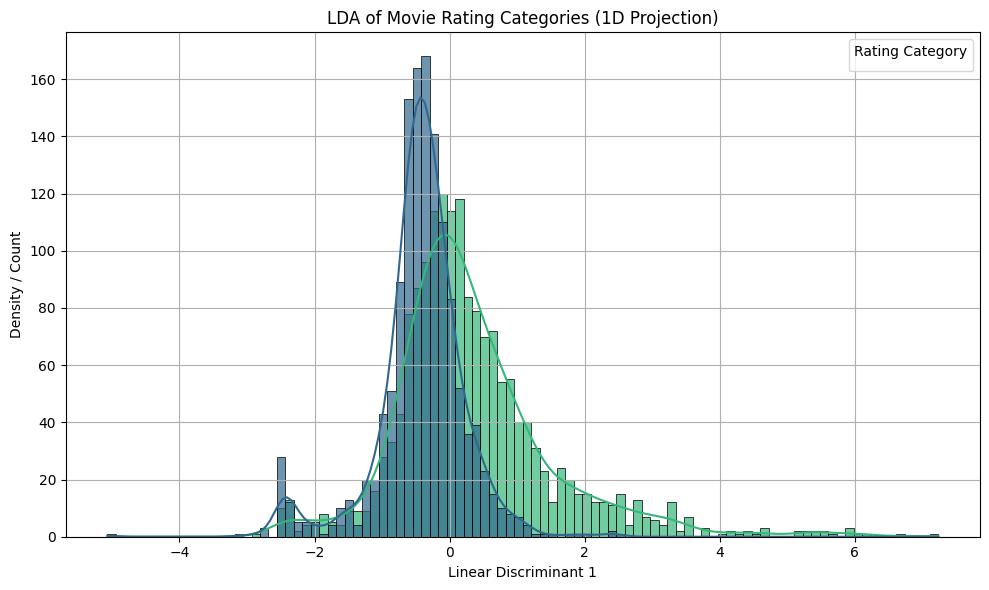


LDA Coefficients (weights of original features for each Linear Discriminant):

     vote_count  popularity    budget  revenue_tmdb   runtime
LD1    0.704323     0.13176 -0.456942      0.040689  0.461617


/tmp/ipython-input-1615652642.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lda_coefficients.iloc[0].loc[top_features_ld1], y=top_features_ld1, palette='rocket')


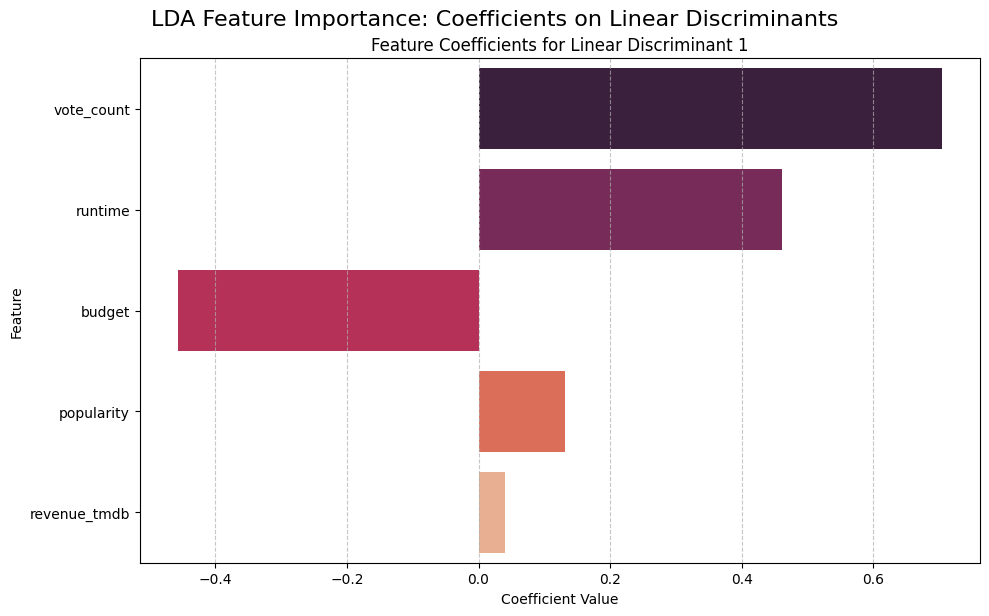

In [ ]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for numerical operations

# --- Step 1: Load the Dataset ---
# If running in Google Colab, make sure you have uploaded 'tmdb_movie_details.csv'
# to your session storage.
try:
    df = pd.read_csv('tmdb_movie_details.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'tmdb_movie_details.csv' not found.")
    print("Please upload the file to your Google Colab session storage.")
    exit() # Exit if the file is not found


# --- Step 2: Data Preprocessing ---
# Define numerical columns relevant for LDA
numerical_features_for_lda = ['vote_average', 'vote_count', 'popularity', 'budget', 'revenue_tmdb', 'runtime']

# Handle missing values by filling with the mean for numerical columns
# This ensures consistency before creating the target and features
for col in numerical_features_for_lda:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Create a binary target variable for LDA based on 'vote_average'
# Movies with vote_average above the mean are 'high' (1), otherwise 'low' (0).
df['rating_category'] = (df['vote_average'] > df['vote_average'].mean()).astype(int)

# Select features (X) and target (y)
# 'vote_average' is used to create the target, so it's excluded from features for LDA
features_for_X = ['vote_count', 'popularity', 'budget', 'revenue_tmdb', 'runtime']
X = df[features_for_X]
y = df['rating_category']

# Check the distribution of the newly created target variable
print("\nDistribution of rating categories (0: Low, 1: High):")
print(y.value_counts())

# Split the data into training and testing sets
# 'stratify=y' ensures that the proportions of each rating category are preserved.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
# Scaling is important for LDA as it is sensitive to the scale of input features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 3: Perform Linear Discriminant Analysis (LDA) ---
# n_components: For binary classification, LDA will produce only 1 discriminant function.
# For multi-class classification with N classes, it produces N-1 discriminants.
# Here, we have 2 classes (0 and 1), so n_components will be 1.
n_components_lda = min(y.nunique() - 1, X.shape[1]) # Will be 1 for binary target

lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

# Display the explained variance ratio by LDA components
# This tells us how much variance each discriminant function accounts for.
print("\nExplained variance ratio by LDA components:")
print(lda.explained_variance_ratio_)

# --- Step 4: Visualize LDA Components ---
# Create a DataFrame for LDA components for easier visualization
# For binary classification, there's only one LD, so we'll plot it as a 1D scatter or histogram.
# If n_components_lda was > 1 (e.g., for 3+ classes), we'd plot LD1 vs LD2.
lda_df_train = pd.DataFrame(data=X_train_lda, columns=[f'LD{i+1}' for i in range(X_train_lda.shape[1])])
lda_df_train['rating_category'] = y_train.reset_index(drop=True) # Ensure index aligns

plt.figure(figsize=(10, 6))
if X_train_lda.shape[1] == 1:
    # For a single discriminant, visualize distribution or a 1D scatter
    sns.histplot(data=lda_df_train, x='LD1', hue='rating_category', kde=True, palette='viridis', alpha=0.7)
    plt.title('LDA of Movie Rating Categories (1D Projection)')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Density / Count')
else:
    # For two or more discriminants, plot LD1 vs LD2
    sns.scatterplot(x='LD1', y='LD2', hue='rating_category', data=lda_df_train, s=70, alpha=0.7, palette='viridis')
    plt.title('LDA of Movie Rating Categories (2D Projection)')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
plt.legend(title='Rating Category')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Step 5: Determine and Visualize Feature Importance (LDA Coefficients) ---
# Feature importance in LDA is derived from the coefficients (coef_)
# The absolute value of coefficients indicates importance for class separation.
# lda.coef_ will have shape (n_classes - 1, n_features)
lda_coefficients = pd.DataFrame(lda.coef_, columns=features_for_X,
                                index=[f'LD{i+1}' for i in range(lda.coef_.shape[0])])

print("\nLDA Coefficients (weights of original features for each Linear Discriminant):\n")
print(lda_coefficients)

plt.figure(figsize=(10, 6))
if lda.coef_.shape[0] == 1: # If only one discriminant
    # Sort by absolute value for better visualization of importance
    top_features_ld1 = lda_coefficients.iloc[0].abs().sort_values(ascending=False).head(len(features_for_X)).index
    sns.barplot(x=lda_coefficients.iloc[0].loc[top_features_ld1], y=top_features_ld1, palette='rocket')
    plt.title('Feature Coefficients for Linear Discriminant 1')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
else: # For multiple LDs (e.g., if we had 3+ classes and n_components_lda > 1)
    # Plot for LD1 coefficients
    plt.subplot(1, 2, 1)
    top_features_ld1 = lda_coefficients.loc['LD1'].abs().sort_values(ascending=False).head(len(features_for_X)).index
    sns.barplot(x=lda_coefficients.loc['LD1', top_features_ld1], y=top_features_ld1, palette='rocket')
    plt.title('Feature Coefficients for LD1')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Plot for LD2 coefficients (if it exists)
    if lda.coef_.shape[0] > 1:
        plt.subplot(1, 2, 2)
        top_features_ld2 = lda_coefficients.loc['LD2'].abs().sort_values(ascending=False).head(len(features_for_X)).index
        sns.barplot(x=lda_coefficients.loc['LD2', top_features_ld2], y=top_features_ld2, palette='rocket')
        plt.title('Feature Coefficients for LD2')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature')
        plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('LDA Feature Importance: Coefficients on Linear Discriminants', y=1.02, fontsize=16)
plt.show()

# **t-Distributed Stochastic Neighbor Embedding (t-SNE)**


First 5 rows of t-SNE results:
| tsne_component_1   | tsne_component_2   |
|:-------------------|:-------------------|
| -54.5687           | 40.507             |
| -54.5682           | 40.3859            |
| -54.546            | 39.5582            |
| -54.5368           | 39.2595            |
| -55.1366           | 38.7894            |


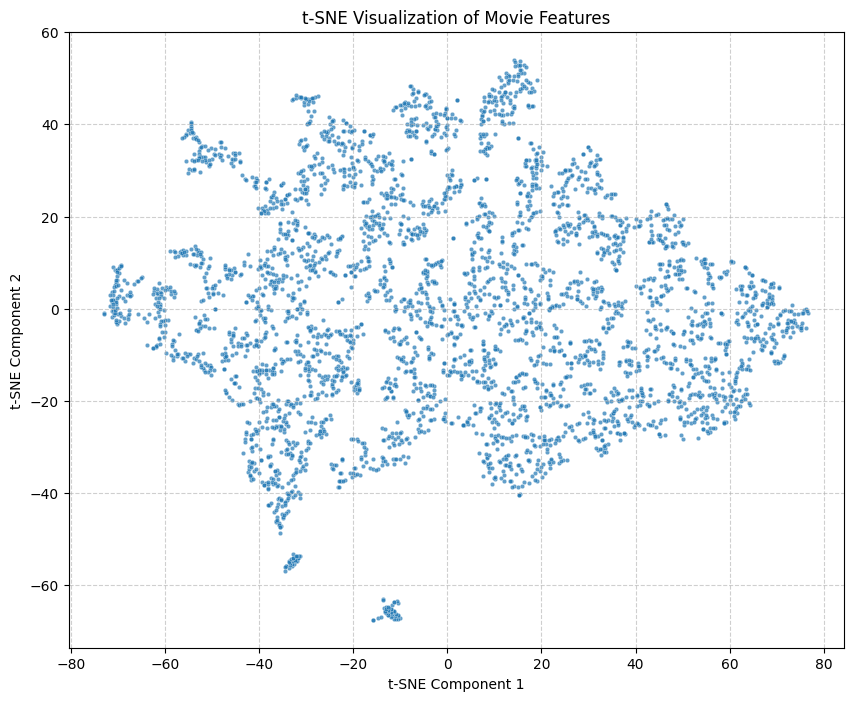

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration ---
FILE_PATH = 'tmdb_movie_details.csv'
NUMERICAL_COLS = ['vote_average', 'vote_count', 'popularity', 'budget', 'revenue_tmdb', 'runtime']
TSNE_COMPONENTS = 2
TSNE_RANDOM_STATE = 42 # For reproducibility
PLOT_TITLE = 't-SNE Visualization of Movie Features'
X_AXIS_LABEL = 't-SNE Component 1'
Y_AXIS_LABEL = 't-SNE Component 2'
OUTPUT_CSV_PATH = 'tmdb_tsne_results.csv'

# --- Functions for better readability and reusability ---
def load_and_preprocess_data(file_path, numerical_cols):
    """Loads the dataset, selects numerical columns, and handles missing values."""
    df = pd.read_csv(file_path)
    df_numerical = df[numerical_cols].copy()

    # Handle missing values by filling with the mean
    for col in numerical_cols:
        if df_numerical[col].isnull().any():
            df_numerical[col].fillna(df_numerical[col].mean(), inplace=True)
    return df_numerical, df # Return original df too if you want to use other columns for plotting later

def scale_features(df_numerical):
    """Scales numerical features using StandardScaler."""
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_numerical)
    return scaled_features

def apply_tsne(scaled_features, n_components=2, random_state=42):
    """Applies t-SNE to the scaled features."""
    tsne = TSNE(n_components=n_components, random_state=random_state)
    tsne_results = tsne.fit_transform(scaled_features)
    return tsne_results

def visualize_tsne(df_tsne, title, x_label, y_label, hue_column=None, original_df=None):
    """Visualizes t-SNE results using a scatter plot."""
    plt.figure(figsize=(10, 8))

    if hue_column and original_df is not None:
        # If you want to color points by a categorical feature from the original df
        # Make sure the original_df and df_tsne have the same number of rows
        plot_df = pd.concat([df_tsne, original_df[hue_column]], axis=1)
        sns.scatterplot(
            x='tsne_component_1',
            y='tsne_component_2',
            hue=hue_column,
            data=plot_df,
            palette='viridis', # Or any other seaborn palette
            alpha=0.7,
            s=10 # Marker size
        )
    else:
        sns.scatterplot(
            x='tsne_component_1',
            y='tsne_component_2',
            data=df_tsne,
            alpha=0.7,
            s=10
        )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- Main execution ---
if __name__ == "__main__":
    # Load and preprocess data
    df_numerical, df_original = load_and_preprocess_data(FILE_PATH, NUMERICAL_COLS)

    # Scale features
    scaled_features = scale_features(df_numerical)

    # Apply t-SNE
    tsne_results = apply_tsne(scaled_features, n_components=TSNE_COMPONENTS, random_state=TSNE_RANDOM_STATE)

    # Create DataFrame for t-SNE results
    df_tsne = pd.DataFrame(data=tsne_results, columns=['tsne_component_1', 'tsne_component_2'])

    # Display first 5 rows of t-SNE results
    print("\nFirst 5 rows of t-SNE results:")
    print(df_tsne.head().to_markdown(index=False, numalign="left", stralign="left"))

    visualize_tsne(df_tsne, PLOT_TITLE, X_AXIS_LABEL, Y_AXIS_LABEL)



# **Sentiment Analysis : NLTK - Natural Language Toolkit**

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download necessary NLTK resources
# These downloads are crucial for NLTK to function correctly.
# 'vader_lexicon' is for the SentimentIntensityAnalyzer.
# 'punkt' is for tokenizing text into words or sentences.
# 'wordnet' and 'omw-1.4' are often used for more advanced NLP tasks like lemmatization,

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')


# Initialize the SentimentIntensityAnalyzer globally to avoid re-initializing in each function call.
# This improves performance by creating the object only once.
sid = SentimentIntensityAnalyzer()

def analyze_and_categorize_sentiment(text):
    """
    Performs sentiment analysis on the given text, calculates individual word scores,
    and returns the compound sentiment score, its category, full polarity scores,
    word-level scores, and the total word count.

    Args:
        text (str): The input text to analyze.

    Returns:
        tuple: A tuple containing:
            - compound_sentiment (float): The compound sentiment score.
            - sentiment_category (str): 'Positive', 'Negative', or 'Neutral'.
            - sentiment_scores (dict): Dictionary of raw polarity scores (neg, neu, pos, compound).
            - word_scores_list (list): A list of tuples, each containing a word and its compound score.
            - word_count (int): The total number of words in the text.
            Returns (None, None, None, None, None) if the input is not a string.
    """
    # Check if the input is a string to prevent errors with non-text data
    if not isinstance(text, str):
        return None, None, None, None, None

    # Calculate overall sentiment scores for the entire text
    sentiment_scores = sid.polarity_scores(text)
    compound_sentiment = sentiment_scores['compound']

    # Tokenize the text into individual words
    # 'punkt' tokenizer is used here.
    tokens = nltk.word_tokenize(text, language='english', preserve_line=True)
    word_scores_list = []
    # Iterate through each token to get its individual compound sentiment score
    for token in tokens:
        word_score = sid.polarity_scores(token)
        word_scores_list.append((token, word_score['compound'])) # Store the word and its compound score

    # Categorize the overall sentiment based on the compound score
    if compound_sentiment >= 0.5:
        sentiment_category = 'Positive'
    elif compound_sentiment <= -0.5:
        sentiment_category = 'Negative'
    else:
        sentiment_category = 'Neutral'

    # Return all calculated values
    return compound_sentiment, sentiment_category, sentiment_scores, word_scores_list, len(tokens)

# Load the dataset from the uploaded CSV file.
# A try-except block is used to handle cases where the file might not be found.
try:
    df = pd.read_csv('tmdb_movie_reviews.csv')
except FileNotFoundError:
    print("Error: 'tmdb_movie_reviews.csv' not found. Please ensure the file is in the correct directory.")
    exit() # Exit the script if the file is not found

# Keeping only the 'author_rating' and 'content' columns
df = df[['author_rating', 'content']]

# Apply the sentiment analysis function to the 'content' column of the DataFrame.
# The .apply() method with pd.Series allows multiple return values from the function to be expanded into new columns in the DataFrame.
df[['sentiment_score', 'sentiment_category', 'full_sentiment_scores', 'word_level_scores', 'word_count']] = \
    df['content'].apply(lambda x: pd.Series(analyze_and_categorize_sentiment(x)))

# Display the results.
# The .head() method shows the first 5 rows by default.
#print("\nSentiment Analysis Results (DataFrame Head - showing word count):")
#print(df[['author_rating', 'word_count', 'sentiment_category']].head())

# Display a more extensive view of the results (first 20 rows) without the DataFrame index.
print("\nFull DataFrame with Sentiment Analysis (first 20 rows for demonstration - showing word count):")
print(df[['author_rating', 'word_count', 'sentiment_category']].head(20).to_string(index=False))




[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



Full DataFrame with Sentiment Analysis (first 20 rows for demonstration - showing word count):
 author_rating  word_count sentiment_category
           7.0         461           Positive
           6.0         314           Negative
           6.0         146           Positive
           2.0          64           Negative
           8.0          76           Positive
           7.0         229           Positive
           8.0         169           Positive
           4.0         715           Positive
           6.0        1624           Positive
           9.0         399           Positive
           7.0         250           Positive
           NaN         119           Positive
           6.0         321           Positive
           NaN         284           Positive
           6.0         178            Neutral
           7.0         105           Positive
           6.0         473           Positive
           8.0         258           Positive
          10.0          89    

In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# ---- downloads (keep as-is) ----
for pkg, path in [
    ('vader_lexicon','sentiment/vader_lexicon.zip'),
    ('punkt','tokenizers/punkt'),
    ('wordnet','corpora/wordnet'),
    ('omw-1.4','corpora/omw-1.4'),
]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg)

sid = SentimentIntensityAnalyzer()

def analyze_and_categorize_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return np.nan, None, None, None, 0
    sentiment_scores = sid.polarity_scores(text)
    compound_sentiment = sentiment_scores['compound']

    # If you don't actually need word-level scores, comment the next 4 lines
    tokens = nltk.word_tokenize(text, language='english', preserve_line=True)
    word_scores_list = [(t, sid.polarity_scores(t)['compound']) for t in tokens]

    if compound_sentiment >= 0.5:
        sentiment_category = 'Positive'
    elif compound_sentiment <= -0.5:
        sentiment_category = 'Negative'
    else:
        sentiment_category = 'Neutral'
    return compound_sentiment, sentiment_category, sentiment_scores, word_scores_list, len(tokens)

# ---- read reviews (IMPORTANT: keep movie_id) ----
def safe_read(path):
    for enc in ['utf-8','utf-8-sig','latin-1']:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    raise FileNotFoundError(path)

reviews = safe_read('tmdb_movie_reviews.csv')

# make sure movie_id exists; keep it along with author_rating/content
keep_cols = [c for c in reviews.columns if c in ['movie_id','author_rating','content']]
assert 'movie_id' in keep_cols, "movie_id missing in reviews CSV"
assert 'content' in keep_cols, "content (review text) missing in reviews CSV"
reviews = reviews[keep_cols]

# apply sentiment function
reviews[['compound','sentiment_category','full_sentiment_scores','word_level_scores','word_count']] = \
    reviews['content'].apply(lambda x: pd.Series(analyze_and_categorize_sentiment(x)))

# --- SAVE row-level (useful for auditing) ---
reviews.to_csv('tmdb_movie_reviews_scored.csv', index=False)

# --- AGGREGATE to movie-level ---
agg = (reviews.groupby('movie_id', dropna=False)
        .agg(sentiment_compound_avg=('compound','mean'),
             reviews_count=('compound','size'),
             pct_pos=('sentiment_category', lambda s: (s=='Positive').mean()),
             pct_neu=('sentiment_category', lambda s: (s=='Neutral').mean()),
             pct_neg=('sentiment_category', lambda s: (s=='Negative').mean()))
        .reset_index())
agg.to_csv('movie_sentiment_agg.csv', index=False)

# --- OPTIONAL: join with details now, or do it later in Power BI ---
details = safe_read('tmdb_movie_details.csv')
# ensure numeric type for merge key
details['movie_id'] = pd.to_numeric(details['movie_id'], errors='coerce')
final = details.merge(agg, on='movie_id', how='left')
final.to_csv('movie_details_with_sentiment.csv', index=False)

print("Wrote files:\n - tmdb_movie_reviews_scored.csv\n - movie_sentiment_agg.csv\n - movie_details_with_sentiment.csv")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Wrote files:
 - tmdb_movie_reviews_scored.csv
 - movie_sentiment_agg.csv
 - movie_details_with_sentiment.csv
